In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('A.A.Cleaned Data set.csvs.csv', encoding='ISO-8859-1')
df


,Request id,Pickup point,Driver id,Status,Request,timestamp,Drop,timestamp.1,Pick_up_Hour,Drop_Hour,Req_Hour_Bucket,Drop_Hour_Bracket,Cancelled Flag,No cars availabe,Time_slot
0,619,Airport,1,Trip Completed,11-Jul-16,11:51:00 AM,11-Jul-16,1:00:00 AM,11,1,11:00-12:00,01:00-02:00,0,0,Morning
1,867,Airport,1,Trip Completed,11-Jul-16,5:57:00 AM,11-Jul-16,6:47:00 AM,5,6,05:00-06:00,06:00-07:00,0,0,Early_Morning
2,1807,City,1,Trip Completed,12-Jul-16,9:17:00 AM,12-Jul-16,9:58:00 AM,9,9,09:00-10:00,09:00-10:00,0,0,Morning
3,2532,Airport,1,Trip Completed,12-Jul-16,9:08:00 AM,12-Jul-16,10:03:00 AM,9,10,09:00-10:00,10:00-11:00,0,0,Morning
4,3112,City,1,Trip Completed,13-Jul-16,8:33:16 AM,13-Jul-16,9:25:47 AM,8,9,08:00-09:00,09:00-10:00,0,0,Morning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6740,6745,City,0,No Cars Available,15-Jul-16,11:49:03 PM,0-Jan-00,NaN,23,0,23:00-24:00,00:00-01:00,0,1,Night
6741,6752,Airport,0,No Cars Available,15-Jul-16,11:50:05 PM,0-Jan-00,NaN,23,0,23:00-24:00,00:00-01:00,0,1,Night
6742,6751,City,0,No Cars Available,15-Jul-16,11:52:06 PM,0-Jan-00,NaN,23,0,23:00-24:00,00:00-01:00,0,1,Night
6743,6754,City,0,No Cars Available,15-Jul-16,11:54:39 PM,0-Jan-00,NaN,23,0,23:00-24:00,00:00-01:00,0,1,Night


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Request id          6745 non-null   int64 
 1   Pickup point        6745 non-null   object
 2   Driver id           6745 non-null   int64 
 3   Status              6745 non-null   object
 4   Request             6745 non-null   object
 5   timestamp           6745 non-null   object
 6   Drop                6745 non-null   object
 7   timestamp.1         2831 non-null   object
 8   Pick_up_Hour        6745 non-null   int64 
 9   Drop_Hour           6745 non-null   int64 
 10  Req_Hour_Bucket     6745 non-null   object
 11  Drop_Hour_Bracket   6745 non-null   object
 12  Cancelled Flag      6745 non-null   int64 
 13  No cars availabe    6745 non-null   int64 
 14  Time_slot           6745 non-null   object
dtypes: int64(6), object(9)
memory usage: 790.6+ KB


In [4]:

df.head()

,Request id,Pickup point,Driver id,Status,Request,timestamp,Drop,timestamp.1,Pick_up_Hour,Drop_Hour,Req_Hour_Bucket,Drop_Hour_Bracket,Cancelled Flag,No cars availabe,Time_slot
0,619,Airport,1,Trip Completed,11-Jul-16,11:51:00 AM,11-Jul-16,1:00:00 AM,11,1,11:00-12:00,01:00-02:00,0,0,Morning
1,867,Airport,1,Trip Completed,11-Jul-16,5:57:00 AM,11-Jul-16,6:47:00 AM,5,6,05:00-06:00,06:00-07:00,0,0,Early_Morning
2,1807,City,1,Trip Completed,12-Jul-16,9:17:00 AM,12-Jul-16,9:58:00 AM,9,9,09:00-10:00,09:00-10:00,0,0,Morning
3,2532,Airport,1,Trip Completed,12-Jul-16,9:08:00 AM,12-Jul-16,10:03:00 AM,9,10,09:00-10:00,10:00-11:00,0,0,Morning
4,3112,City,1,Trip Completed,13-Jul-16,8:33:16 AM,13-Jul-16,9:25:47 AM,8,9,08:00-09:00,09:00-10:00,0,0,Morning


In [35]:
df['Request']=pd.to_datetime(df['Request'],format='%d-%b-%y') 
df['Request'] = df['Request'].ffill()

In [6]:
df.shape

(6745, 15)

In [37]:
df.isnull().sum()

Request id               0
Pickup point             0
Driver id                0
Status                   0
Request                  0
timestamp                0
Drop                     0
timestamp.1           6745
Pick_up_Hour             0
Drop_Hour                0
Req_Hour_Bucket          0
Drop_Hour_Bracket        0
Cancelled Flag           0
No cars availabe         0
Time_slot                0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Request id          6745 non-null   int64         
 1   Pickup point        6745 non-null   object        
 2   Driver id           6745 non-null   int64         
 3   Status              6745 non-null   object        
 4   Request             6745 non-null   datetime64[ns]
 5   timestamp           6745 non-null   object        
 6   Drop                6745 non-null   object        
 7   timestamp.1         2831 non-null   object        
 8   Pick_up_Hour        6745 non-null   int64         
 9   Drop_Hour           6745 non-null   int64         
 10  Req_Hour_Bucket     6745 non-null   object        
 11  Drop_Hour_Bracket   6745 non-null   object        
 12  Cancelled Flag      6745 non-null   int64         
 13  No cars availabe    6745 non-null   int64       

In [27]:
df['timestamp.1'] = df['timestamp.1'].astype(str).str.strip()
df['timestamp.1'] = pd.to_datetime(df['timestamp.1'], format='%I:%M:%S %p', errors='coerce')



In [11]:
df['Drop']=pd.to_datetime(df['Drop'],format='%d-%b-%y',errors='coerce')

In [12]:
df['timestamp']=pd.to_datetime(df['timestamp'],errors='coerce')

C:\Users\Admin\AppData\Local\Temp\ipykernel_16588\3409107855.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['timestamp']=pd.to_datetime(df['timestamp'],errors='coerce')


In [13]:
df['Drop'] = df['Drop'].ffill()

In [24]:
df['timestamp.1'] = df['timestamp.1'].ffill().bfill()

In [18]:
df.drop_duplicates(subset='Request id',inplace=True)  

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Request id          6745 non-null   int64         
 1   Pickup point        6745 non-null   object        
 2   Driver id           6745 non-null   int64         
 3   Status              6745 non-null   object        
 4   Request             6745 non-null   datetime64[ns]
 5   timestamp           6745 non-null   datetime64[ns]
 6   Drop                6745 non-null   datetime64[ns]
 7   timestamp.1         0 non-null      datetime64[ns]
 8   Pick_up_Hour        6745 non-null   int64         
 9   Drop_Hour           6745 non-null   int64         
 10  Req_Hour_Bucket     6745 non-null   object        
 11  Drop_Hour_Bracket   6745 non-null   object        
 12  Cancelled Flag      6745 non-null   int64         
 13  No cars availabe    6745 non-null   int64       

In [29]:
df.isnull().sum()


Request id               0
Pickup point             0
Driver id                0
Status                   0
Request                  0
timestamp                0
Drop                     0
timestamp.1           6745
Pick_up_Hour             0
Drop_Hour                0
Req_Hour_Bucket          0
Drop_Hour_Bracket        0
Cancelled Flag           0
No cars availabe         0
Time_slot                0
dtype: int64

In [39]:
df.drop('timestamp.1',axis=1,inplace=True)

In [40]:
df

,Request id,Pickup point,Driver id,Status,Request,timestamp,Drop,Pick_up_Hour,Drop_Hour,Req_Hour_Bucket,Drop_Hour_Bracket,Cancelled Flag,No cars availabe,Time_slot
0,619,Airport,1,Trip Completed,2016-07-11,2026-03-13 11:51:00,2016-07-11,11,1,11:00-12:00,01:00-02:00,0,0,Morning
1,867,Airport,1,Trip Completed,2016-07-11,2026-03-13 05:57:00,2016-07-11,5,6,05:00-06:00,06:00-07:00,0,0,Early_Morning
2,1807,City,1,Trip Completed,2016-07-12,2026-03-13 09:17:00,2016-07-12,9,9,09:00-10:00,09:00-10:00,0,0,Morning
3,2532,Airport,1,Trip Completed,2016-07-12,2026-03-13 09:08:00,2016-07-12,9,10,09:00-10:00,10:00-11:00,0,0,Morning
4,3112,City,1,Trip Completed,2016-07-13,2026-03-13 08:33:16,2016-07-13,8,9,08:00-09:00,09:00-10:00,0,0,Morning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6740,6745,City,0,No Cars Available,2016-07-15,2026-03-13 23:49:03,2016-07-15,23,0,23:00-24:00,00:00-01:00,0,1,Night
6741,6752,Airport,0,No Cars Available,2016-07-15,2026-03-13 23:50:05,2016-07-15,23,0,23:00-24:00,00:00-01:00,0,1,Night
6742,6751,City,0,No Cars Available,2016-07-15,2026-03-13 23:52:06,2016-07-15,23,0,23:00-24:00,00:00-01:00,0,1,Night
6743,6754,City,0,No Cars Available,2016-07-15,2026-03-13 23:54:39,2016-07-15,23,0,23:00-24:00,00:00-01:00,0,1,Night


In [44]:
df.shape

(6745, 15)

In [41]:
df['Trip_complete']=np.where(df['Status']=='Trip Completed','True','False')


In [42]:
df

,Request id,Pickup point,Driver id,Status,Request,timestamp,Drop,Pick_up_Hour,Drop_Hour,Req_Hour_Bucket,Drop_Hour_Bracket,Cancelled Flag,No cars availabe,Time_slot,Trip_complete
0,619,Airport,1,Trip Completed,2016-07-11,2026-03-13 11:51:00,2016-07-11,11,1,11:00-12:00,01:00-02:00,0,0,Morning,True
1,867,Airport,1,Trip Completed,2016-07-11,2026-03-13 05:57:00,2016-07-11,5,6,05:00-06:00,06:00-07:00,0,0,Early_Morning,True
2,1807,City,1,Trip Completed,2016-07-12,2026-03-13 09:17:00,2016-07-12,9,9,09:00-10:00,09:00-10:00,0,0,Morning,True
3,2532,Airport,1,Trip Completed,2016-07-12,2026-03-13 09:08:00,2016-07-12,9,10,09:00-10:00,10:00-11:00,0,0,Morning,True
4,3112,City,1,Trip Completed,2016-07-13,2026-03-13 08:33:16,2016-07-13,8,9,08:00-09:00,09:00-10:00,0,0,Morning,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6740,6745,City,0,No Cars Available,2016-07-15,2026-03-13 23:49:03,2016-07-15,23,0,23:00-24:00,00:00-01:00,0,1,Night,False
6741,6752,Airport,0,No Cars Available,2016-07-15,2026-03-13 23:50:05,2016-07-15,23,0,23:00-24:00,00:00-01:00,0,1,Night,False
6742,6751,City,0,No Cars Available,2016-07-15,2026-03-13 23:52:06,2016-07-15,23,0,23:00-24:00,00:00-01:00,0,1,Night,False
6743,6754,City,0,No Cars Available,2016-07-15,2026-03-13 23:54:39,2016-07-15,23,0,23:00-24:00,00:00-01:00,0,1,Night,False


# Request Distrubution by Time_slot 



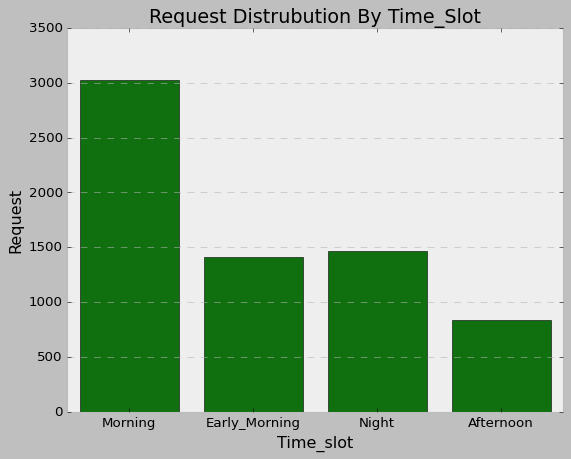

In [54]:
sns.countplot(data=df,x='Time_slot',color='green',edgecolor='black') 
plt.title('Request Distrubution By Time_Slot')
plt.xlabel('Time_slot')
plt.ylabel('Request')
plt.show()

# Total Rides BY Time Slot


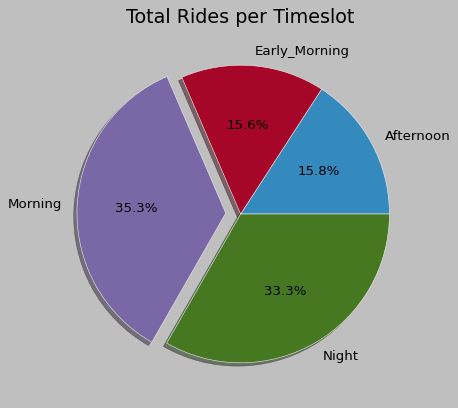

In [56]:

timeslot_counts = df.groupby('Time_slot')['Request id'].sum()


# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(timeslot_counts.values,labels=timeslot_counts.index,autopct='%1.1f%%',shadow=True,explode=(0,0,0.1,0))
plt.title('Total Rides per Timeslot')
plt.show()


# Status wise Request ID

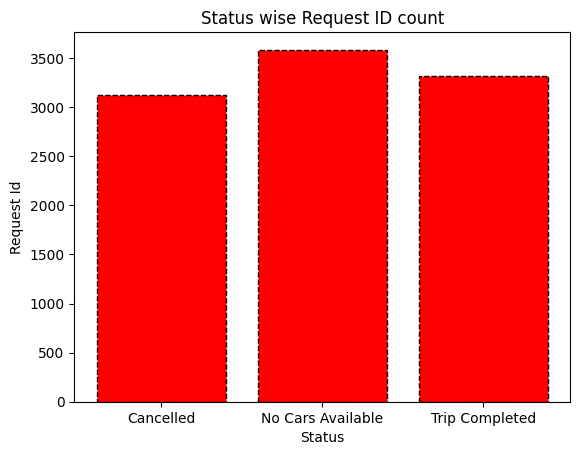

In [4]:
Trip_status=df.groupby('Status')['Request id'].mean()
plt.bar(Trip_status.index,Trip_status.values,color='red',edgecolor='black',linestyle='--') 
plt.title('Status wise Request ID count') 
plt.xlabel('Status') 
plt.ylabel('Request Id')
plt.show()

# Cancelled Request By Hour_Bucket

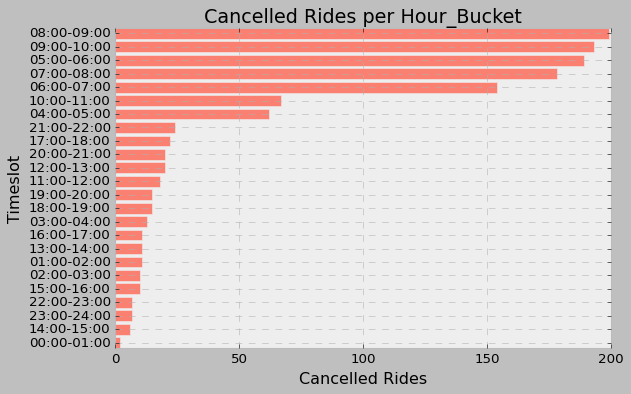

In [58]:

df_cancelled = df.groupby('Req_Hour_Bucket')['Cancelled Flag'].sum().sort_values().reset_index()
plt.figure(figsize=(8,5))
plt.barh(df_cancelled['Req_Hour_Bucket'], df_cancelled['Cancelled Flag'], color='salmon')
plt.title('Cancelled Rides per Hour_Bucket')
plt.xlabel('Cancelled Rides')
plt.ylabel('Timeslot')
plt.show()

# Time Slot vs Status

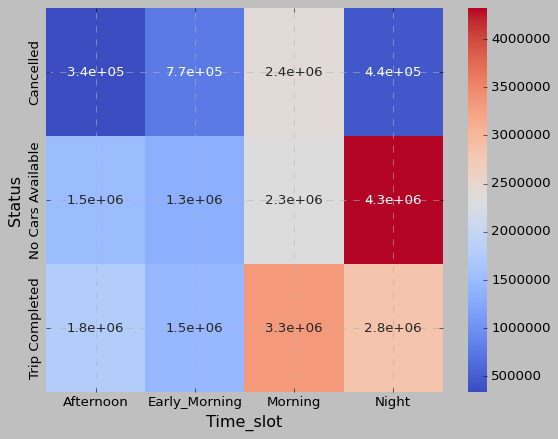

In [59]:
pivot_tables=df.pivot_table( 
    values='Request id',
    index='Status',
    columns='Time_slot',
    aggfunc='sum') 
sns.heatmap(pivot_tables,annot=True,cmap='coolwarm') 
plt.show()

# Airport request Count and City Request Count

In [112]:
Airport = df[df['Pickup point'] == 'Airport']['Request id'].count()
City=df[df['Pickup point']=='City']['Request id'].count()
print('Airport_Request:',Airport)
print('City_Request:',City)

Airport_Request: 3238
City_Request: 3507


# Reuquest wise Trip_complete

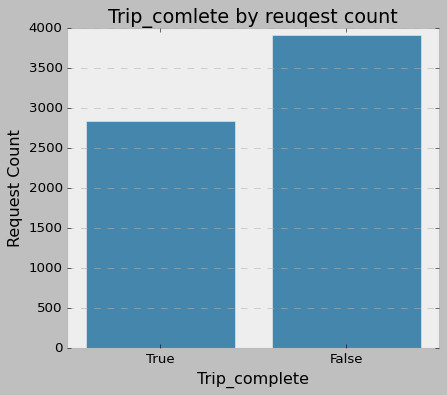

In [60]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='Trip_complete')
plt.title('Trip_comlete by reuqest count')
plt.xlabel('Trip_complete')
plt.ylabel('Request Count')
plt.show()

# Cancelled Flag vs Time slot vs Request by cancellation%

In [131]:

df_eda = df.groupby('Time_slot').agg({'Request id':'count','Cancelled Flag':'sum'}).reset_index()
df_eda['Cancellation %'] = (df_eda['Cancelled Flag']/df_eda['Request id'])*100
print(df_eda)

       Time_slot  Request id  Cancelled Flag  Cancellation %
0      Afternoon         837              80        9.557945
1  Early_Morning        1414             287       20.297030
2        Morning        3025             809       26.743802
3          Night        1469              88        5.990470
